# Swing Trading vs. Investing

**16.6 years, two markets, 2.3 million daily bars.**

This notebook asks a question that sounds simple and is not: *is actively trading a validated
quantitative swing system better than just buying and holding?*

The swing side is not a strawman. It is the live configuration of
[`swing-quant`](../README.md) — two sleeves that passed a 10-point validation protocol
(walk-forward, out-of-sample, Monte Carlo, block bootstrap, cost stress, random baseline):
Donchian breakout on the B3 and cross-sectional momentum on US large caps. Same engine, same
costs, same risk rules that run in production.

The investing side is not a strawman either. It is four baselines, not one: the index, an
equal-weight portfolio of the same universe, the risk-free rate, and — most importantly — a
passive portfolio deliberately held at the *same average equity exposure* as the swing book.

The headline result is that the naive comparison ("did the strategy beat the index?") answers
the wrong question, and that in Brazil **most of what looks like trading skill is interest on
idle cash**.


## 0. Setup

Everything below is computed from the project's own DuckDB store and its production backtest
engine. `study_lib.py` (next to this notebook) only wires those together and adds the pieces
the engine deliberately leaves out: interest on idle cash, taxes, and the passive baselines.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
import study_lib as S

S.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

STUDIES = {m: S.build_study(m) for m in ("b3", "us")}
B3, US = STUDIES["b3"], STUDIES["us"]

for m, s in STUDIES.items():
    print(
        f"{S.MARKET_LABEL[m]:<18} {s.index[0].date()} -> {s.index[-1].date()}  "
        f"({s.years:.1f}y, {len(s.index):,} sessions)  "
        f"universe={len(s.md.tickers)}  strategy={', '.join(s.md.strategies)}  "
        f"trades={len(s.result.trades):,}"
    )

Brazil (B3)        2010-01-04 -> 2026-08-27  (16.6y, 4,138 sessions)  universe=98  strategy=donchian  trades=615
United States      2010-01-04 -> 2026-08-27  (16.6y, 4,188 sessions)  universe=503  strategy=momentum  trades=3,795


## 1. The data

| | Brazil | United States |
|---|---|---|
| Universe | IBrX-100 (current members) | S&P 500 (current members) |
| Benchmark | `^BVSP` (Ibovespa, total return) | `SPY` (total return) |
| Risk-free | CDI, daily, from the Central Bank SGS series 12 | 1–3 month T-bills, via `BIL` total return |
| Prices | Yahoo Finance OHLCV, dividend-adjusted | same |
| Period | 2010-01-04 → 2026-08-27 | 2010-01-04 → 2026-08-27 |

Prices are adjusted so that the whole OHLC bar sits on a total-return basis (the project's
ADR-009): the adjustment factor `adj_close / close` is applied to open, high and low too, so a
stop or an open-price fill is measured on the same footing as the close.

Two things about this dataset are worth stating up front, because they bound every number that
follows.

**Survivorship.** The universe is the index as it stands *today*, walked backwards. Companies
that were dropped from the IBrX-100 or the S&P 500 are missing, and they are missing precisely
because they did badly. This inflates the passive baselines more than it inflates the swing
system — buy-and-hold holds every name for the whole period, while the swing system only holds
a name for a few weeks at a time. The equal-weight baseline is the worst affected of all and
should be read as an optimistic upper bound, not as an achievable portfolio.

**One path.** 16.6 years is one realisation of history, not a distribution. Every point estimate
below is a single draw; the rolling-window sections exist to give some sense of the spread
around it.


In [2]:
provenance = pd.DataFrame(
    {
        S.MARKET_LABEL[m]: {
            "sessions": f"{len(s.index):,}",
            "tickers in universe": len(s.md.tickers),
            "price rows": f"{len(s.md.prices):,}",
            "names alive on day 1": s.n_alive,
            "benchmark": "^BVSP" if m == "b3" else "SPY",
            "risk-free": s.md.rf_label,
            "risk-free CAGR": f"{S.curve_stats(s.risk_free, s.md.rf_daily)['cagr']:.2%}",
            "starting capital": f"{s.md.currency} {s.capital:,.0f}",
        }
        for m, s in STUDIES.items()
    }
)
provenance

,Brazil (B3),United States
sessions,"4,138","4,188"
tickers in universe,98,503
price rows,"327,183","1,974,058"
names alive on day 1,60,419
benchmark,^BVSP,SPY
risk-free,CDI,T-bills
risk-free CAGR,9.77%,1.34%
starting capital,"R$ 100,000","US$ 20,000"


## 2. What is actually being compared

### The swing system

Both sleeves are long-only, hold for days to weeks, and are sized by volatility rather than by
a fixed fraction of capital. A signal at the close of day *D* is executed at the **open of
D+1** — no same-bar fills, no closing-price fantasies. Costs are charged on both legs:
brokerage, exchange fees, and slippage against the trader.

Position size comes from risk, not conviction: `qty = (risk_per_trade x equity) / (k x ATR)`,
capped by a maximum position weight, by participation in the average traded volume, and by
available cash. That last cap is the reason this whole study exists — a book sized by risk
spends most of its life mostly in cash.

### The four passive baselines

1. **Index buy & hold** — one purchase on day one, held to the end, dividends reinvested.
2. **Equal-weight buy & hold** — the same money split evenly across every name that already
   traded on day one, then never touched. No rebalancing, so no invented turnover cost.
3. **Risk-free** — CDI in Brazil, T-bills in the US.
4. **The blend** — `w` in the index and `1 − w` at the risk-free rate, rebalanced daily. Two
   versions: `w` set to the swing book's average exposure, and `w` set so the blend's
   volatility matches the swing book's.

The blend is the only honest comparison, and section 4 explains why.


In [3]:
from swing_quant.config import load_config

cfg = load_config(S.CONFIG_PATH)
for m, s in STUDIES.items():
    name = s.md.strategies[0]
    costs, risk = S.build_models(m, cfg)
    print(f"--- {S.MARKET_LABEL[m]} : {name}")
    print(f"    params        {cfg.strategies.get(name, {})}")
    print(
        f"    risk/trade    {risk.risk_per_trade:.2%} of equity, stop at "
        f"{risk.atr_multiple}x ATR, max {risk.max_positions} positions, "
        f"max {risk.max_position_pct:.0%} per name"
    )
    print(f"    costs/leg     fees {costs.fees_pct:.4%} + slippage {costs.slippage_pct:.3%}")

--- Brazil (B3) : donchian
    params        {'enabled': True, 'markets': ['b3'], 'entry_lookback': 40, 'exit_lookback': 10, 'volume_mult': 1.5, 'stop_atr': 2.0}
    risk/trade    0.50% of equity, stop at 2.0x ATR, max 6 positions, max 20% per name
    costs/leg     fees 0.0300% + slippage 0.100%
--- United States : momentum
    params        {'enabled': True, 'markets': ['us'], 'lookback': 189, 'skip': 21, 'exit_sma': 50, 'max_hold': 63, 'stop_atr': 3.0}
    risk/trade    0.35% of equity, stop at 2.0x ATR, max 6 positions, max 20% per name
    costs/leg     fees 0.0010% + slippage 0.050%


## 3. The headline table

Sharpe and Sortino here are measured against the **actual daily risk-free series**, not against
zero. In Brazil that is not a technicality: CDI compounded to 9.8% a year over this period, so
a zero-rate Sharpe would flatter every Brazilian strategy by roughly half a point and would
rank a 5% strategy above cash that paid 10%.


In [4]:
COLS = [
    "cagr",
    "volatility",
    "sharpe",
    "sortino",
    "max_drawdown",
    "max_dd_days",
    "calmar",
    "excess_over_rf",
    "final",
]

for m, s in STUDIES.items():
    print(
        f"\n=== {S.MARKET_LABEL[m]} — {s.md.currency} {s.capital:,.0f} initial, {s.years:.1f} years"
    )
    display(S.fmt_table(s.table()[COLS]))


=== Brazil (B3) — R$ 100,000 initial, 16.6 years


,cagr,volatility,sharpe,sortino,max_drawdown,max_dd_days,calmar,excess_over_rf,final
Swing (cash at 0%),5.1%,6.6%,-0.64,-0.86,-10.8%,627,0.47,-4.7%,"228,195"
Swing (cash at CDI),12.4%,6.6%,0.39,0.55,-8.8%,201,1.40,2.6%,"695,014"
29% index + CDI,9.2%,6.5%,-0.05,-0.07,-15.0%,202,0.61,-0.6%,"429,976"
29% index + CDI (vol-matched),9.1%,6.6%,-0.05,-0.07,-15.2%,202,0.60,-0.6%,"429,371"
Index buy & hold,5.7%,22.9%,-0.05,-0.07,-48.6%,"1,694",0.12,-4.1%,"250,032"
Equal-weight B&H (60),11.5%,18.9%,0.18,0.25,-40.9%,498,0.28,1.8%,"614,424"
CDI,9.8%,0.2%,-,-,0.0%,0,-,-0.0%,"471,679"



=== United States — US$ 20,000 initial, 16.6 years


,cagr,volatility,sharpe,sortino,max_drawdown,max_dd_days,calmar,excess_over_rf,final
Swing (cash at 0%),9.5%,8.2%,0.98,1.40,-12.9%,573,0.73,8.1%,"89,914"
Swing (cash at T-bills),10.5%,8.2%,1.10,1.58,-13.0%,545,0.81,9.2%,"105,764"
28% index + T-bills,5.1%,4.8%,0.79,1.11,-10.1%,353,0.50,3.7%,"45,571"
48% index + T-bills (vol-matched),7.7%,8.2%,0.79,1.11,-17.3%,373,0.45,6.4%,"69,206"
Index buy & hold,14.2%,17.1%,0.79,1.11,-33.7%,488,0.42,12.9%,"182,340"
Equal-weight B&H (419),17.7%,17.9%,0.93,1.31,-34.7%,384,0.51,16.4%,"301,356"
T-bills,1.3%,0.3%,-,-,-0.4%,"1,865",3.10,0.0%,"24,951"


Read the two markets separately, because they tell opposite stories.

**Brazil.** The Ibovespa returned 5.7% a year while CDI paid 9.8%. Sixteen and a half years of
equity risk — a 48.6% drawdown, 1,694 sessions (6.7 years) below the previous high — to end up
behind a money-market account. Against that backdrop almost anything looks good. The swing
book, with interest credited on its cash, made 12.4% a year with an 8.8% worst drawdown.

**United States.** The opposite. SPY compounded at 14.2% and equal-weight at 17.7%, while
T-bills paid 1.3%. The swing book made 10.5%. It lost, and it lost by a lot: 4 percentage
points a year, which over 16.6 years is the difference between US$106k and US$182k on a
US$20k stake.

And yet the swing book has a *higher Sharpe ratio than the index in both markets* — 0.39 vs
−0.05 in Brazil, 1.10 vs 0.79 in the US. That contradiction is the whole study.


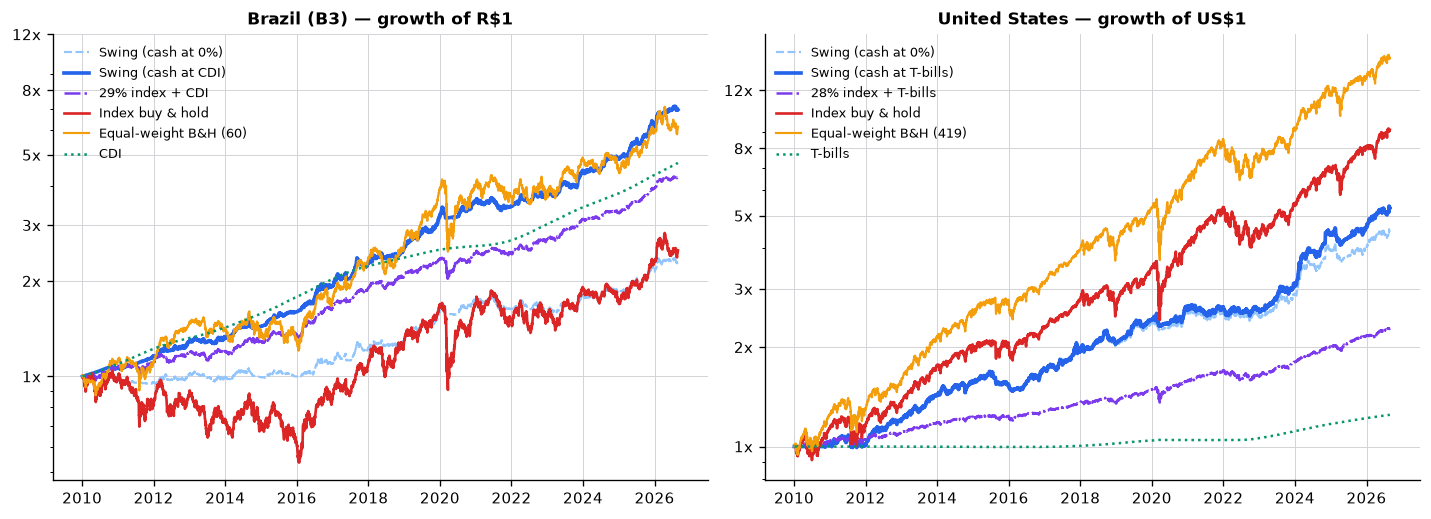

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
STYLE = {
    "Swing (cash at 0%)": (S.COLORS["swing_raw"], 1.3, "--"),
    "Index buy & hold": (S.COLORS["index"], 1.6, "-"),
    "Equal-weight B&H": (S.COLORS["equal_weight"], 1.3, "-"),
}
for ax, (m, s) in zip(axes, STUDIES.items()):
    for name, curve in s.curves().items():
        key = next((k for k in STYLE if name.startswith(k.split(" (")[0])), None)
        if name.startswith("Swing (cash at 0%)"):
            color, lw, ls = S.COLORS["swing_raw"], 1.3, "--"
        elif name.startswith("Swing (cash at"):
            color, lw, ls = S.COLORS["swing"], 2.2, "-"
        elif name.startswith("Index"):
            color, lw, ls = S.COLORS["index"], 1.6, "-"
        elif name.startswith("Equal-weight"):
            color, lw, ls = S.COLORS["equal_weight"], 1.3, "-"
        elif "vol-matched" in name:
            continue
        elif "index +" in name:
            color, lw, ls = S.COLORS["blend"], 1.5, "-."
        else:
            color, lw, ls = S.COLORS["risk_free"], 1.5, ":"
        ax.plot(curve.index, curve / s.capital, color=color, lw=lw, ls=ls, label=name)
    ax.set_yscale("log")
    ax.set_yticks([1, 2, 3, 5, 8, 12])
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}x"))
    ax.set_title(f"{S.MARKET_LABEL[m]} — growth of {s.md.currency}1")
    ax.legend(fontsize=7.5, loc="upper left")
fig.tight_layout()
fig.savefig(FIGDIR / "01_equity.png", bbox_inches="tight")
plt.show()

## 4. The exposure problem

A swing book sized by risk does not hold stocks. It holds *a little bit* of stocks and a large
pile of cash, and the pile is much larger than most people assume.


In [6]:
exposure = pd.DataFrame(
    {
        S.MARKET_LABEL[m]: {
            "average equity exposure": f"{s.exposure_avg:.1%}",
            "average cash weight": f"{s.cash_weight.mean():.1%}",
            "days fully in cash": f"{(s.result.n_positions == 0).mean():.1%}",
            "median open positions": f"{s.result.n_positions.median():.0f}",
            "annualised volatility": f"{s.swing.pct_change().std(ddof=1) * np.sqrt(252):.1%}",
            "index volatility": f"{s.bench.pct_change().std(ddof=1) * np.sqrt(252):.1%}",
        }
        for m, s in STUDIES.items()
    }
)
exposure

,Brazil (B3),United States
average equity exposure,28.5%,27.8%
average cash weight,71.4%,72.2%
days fully in cash,13.1%,5.0%
median open positions,4,6
annualised volatility,6.6%,8.2%
index volatility,22.9%,17.1%


Roughly **72% of the book is cash, on average, in both markets.** That single number invalidates
the comparison everyone reaches for first.

Comparing a 28%-invested portfolio to a 100%-invested index is not a test of trading skill. It
is mostly a test of how equities happened to do. If stocks went up, the 100%-invested portfolio
wins by construction; if they went down, the 28%-invested one wins by construction. Neither
outcome says anything about whether the entry and exit rules add value.

There are two ways to fix it, and the study uses both:

- **Match the exposure.** Hold `w = 28%` of the index and the rest at the risk-free rate. Same
  average equity exposure, no timing, no skill.
- **Match the volatility.** Choose `w` so the passive blend has the same annualised volatility
  as the swing book. In Brazil that is also ~29%; in the US it is 48%, because the swing book
  there is more volatile than its exposure suggests.

Once the exposure is matched, the question becomes the right one: *given the same amount of
equity risk, did the trading rules beat holding the index and doing nothing?*


## 5. Finding 1 — in Brazil, most of the "trading profit" is interest

The backtest engine keeps idle cash at 0% on purpose, which is conservative for a validation
protocol and badly misleading for a comparison against investing. A Brazilian broker account
paying 100% of CDI turns 72% of a swing book into a money-market fund. So the honest curve
credits the cash: each day's portfolio return plus `cash_weight × risk-free`.

Then it becomes fair to ask how much of the result came from the trades and how much came from
the cash sitting behind them.


In [7]:
attr = pd.DataFrame({S.MARKET_LABEL[m]: s.attribution() for m, s in STUDIES.items()}).T
show = attr.copy()
for c in ("total", "trading", "cash", "cross", "cash_share"):
    show[c] = show[c].map("{:.2%}".format)
for c in ("interest_total", "trading_pnl"):
    show[c] = show[c].map("{:,.0f}".format)
show

,total,trading,cash,cross,cash_share,interest_total,trading_pnl
Brazil (B3),12.35%,5.08%,6.92%,0.35%,56.03%,"301,863","128,120"
United States,10.52%,9.45%,0.98%,0.09%,9.32%,"11,392","69,907"


In Brazil, of the 12.35% annual return, **6.92 points came from the cash sleeve and 5.08 from
the trades — 56% of the strategy's compound return was interest**. Turn the CDI credit off and
the same system makes 5.1% a year, which loses to a savings-account alternative by 4.7 points
annually.

In the US the same decomposition gives 9%, because the strategy ran through a decade of
zero rates. The strategy is identical in spirit; the environment is what differs.

This reframes the product. A swing book run at 0.5% risk per trade is not an equity strategy.
It is a **money-market fund with a small equity overlay**, and in a high-rate country most of
its return is the fund, not the overlay.


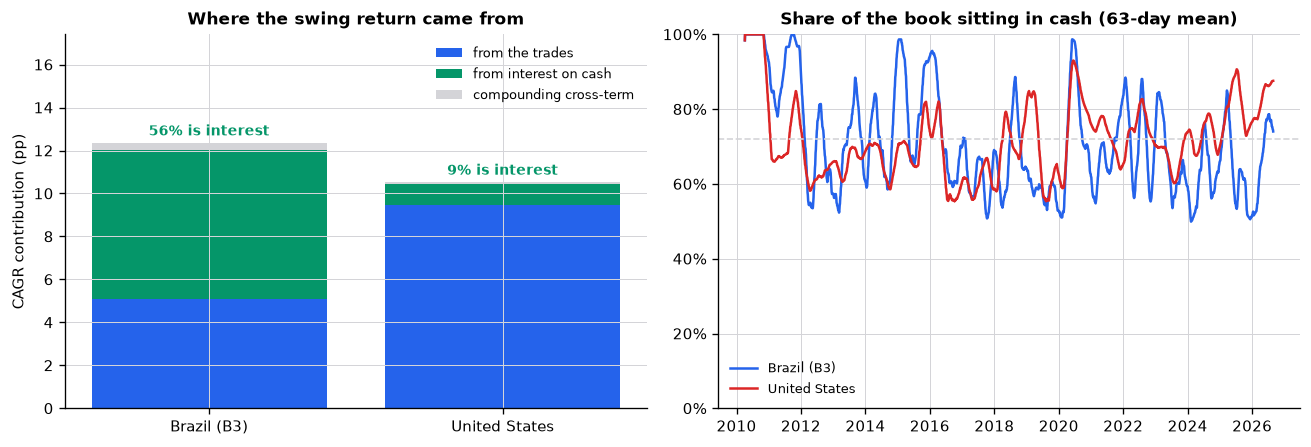

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
labels = [S.MARKET_LABEL[m] for m in STUDIES]
trading = [STUDIES[m].attribution()["trading"] * 100 for m in STUDIES]
cash = [STUDIES[m].attribution()["cash"] * 100 for m in STUDIES]
cross = [STUDIES[m].attribution()["cross"] * 100 for m in STUDIES]
ax.bar(labels, trading, color=S.COLORS["swing"], label="from the trades")
ax.bar(labels, cash, bottom=trading, color=S.COLORS["risk_free"], label="from interest on cash")
ax.bar(
    labels,
    cross,
    bottom=np.add(trading, cash),
    color=S.COLORS["grid"],
    label="compounding cross-term",
)
for i, m in enumerate(STUDIES):
    a = STUDIES[m].attribution()
    ax.text(
        i,
        a["total"] * 100 + 0.35,
        f"{a['cash_share']:.0%} is interest",
        ha="center",
        fontsize=8.5,
        color=S.COLORS["risk_free"],
        weight="bold",
    )
ax.set_ylabel("CAGR contribution (pp)")
ax.set_ylim(0, max(t + c for t, c in zip(trading, cash)) * 1.45)
ax.set_title("Where the swing return came from")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
for m, s in STUDIES.items():
    ax.plot(
        s.cash_weight.index,
        s.cash_weight.rolling(63).mean(),
        label=S.MARKET_LABEL[m],
        lw=1.5,
        color=S.COLORS["swing"] if m == "b3" else S.COLORS["index"],
    )
ax.axhline(0.72, color=S.COLORS["grid"], lw=1, ls="--")
ax.set_ylim(0, 1)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Share of the book sitting in cash (63-day mean)")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGDIR / "02_attribution.png", bbox_inches="tight")
plt.show()

## 6. Finding 2 — the "edge over the index" is mostly a rate signal

If a large part of the swing return is interest, then how good swing trading *looks* should
depend on the interest rate — and it should stop depending on it once the comparison holds the
same cash.

Splitting every overlapping 1-year window into quartiles by the prevailing rate tests exactly
that. `vs_index` is the swing book's excess over buying the index; `vs_blend` is its excess over
the exposure-matched passive blend, which holds the same cash and therefore earns the same
interest.


In [9]:
for m, s in STUDIES.items():
    rq = s.rate_quartiles()
    out = rq.assign(
        **{
            c: rq[c].map("{:+.1%}".format)
            for c in ("rate", "swing", "index", "vs_index", "vs_blend")
        }
    )
    print(f"\n=== {S.MARKET_LABEL[m]}  (overlapping 1-year windows)")
    display(out)
    print(
        f"    corr(rate, vs_index) = {rq.attrs['corr_vs_index']:+.2f}    "
        f"corr(rate, vs_blend) = {rq.attrs['corr_vs_blend']:+.2f}"
    )


=== Brazil (B3)  (overlapping 1-year windows)


,rate,swing,index,vs_index,vs_blend,n
rate_quartile,,,,,,
Q1 (lowest),+5.0%,+12.1%,+12.4%,-0.3%,+4.5%,972
Q2,+9.0%,+9.1%,+0.5%,+8.6%,+2.3%,971
Q3,+11.6%,+12.2%,+1.5%,+10.7%,+3.3%,971
Q4 (highest),+13.8%,+18.0%,+16.0%,+2.0%,+3.4%,972


    corr(rate, vs_index) = +0.11    corr(rate, vs_blend) = -0.03

=== United States  (overlapping 1-year windows)


,rate,swing,index,vs_index,vs_blend,n
rate_quartile,,,,,,
Q1 (lowest),-0.1%,+7.7%,+17.0%,-9.3%,+3.2%,986
Q2,+0.0%,+7.5%,+14.5%,-7.0%,+3.5%,982
Q3,+1.1%,+9.7%,+10.2%,-0.5%,+5.8%,984
Q4 (highest),+4.2%,+19.4%,+18.2%,+1.2%,+11.2%,984


    corr(rate, vs_index) = +0.38    corr(rate, vs_blend) = +0.48


Brazil gives a clean result. Measured against the index, the swing book's edge lurches from
−0.3% to +10.7% depending on the quartile. Measured against the blend that holds the same cash,
it sits in a narrow band — **+2.3% to +4.5%, with a correlation to the rate level of −0.03.**

That is the finding. The apparent edge over the index is dominated by the rate; the residual
edge over a cash-matched passive portfolio is small, stable and real — **3.2 percentage points
a year of actual trading skill** (12.35% against the blend's 9.16%), not the 6.7 points the naive index comparison advertises.

The US table does not decompose as cleanly: `vs_blend` still climbs with rates (correlation
+0.48). The honest reading is that this is confounded rather than causal — the high-rate
quartile in the US is 2023–2026, which is also when this particular momentum strategy did its
best work. With one path through history there is no way to separate the two, and I would not
claim the rate caused it.


## 7. Finding 3 — the risk numbers go the other way

Everything so far has been about return. Drawdown tells a different story, and it is the one
that matters to whether a person can actually stay in the seat.


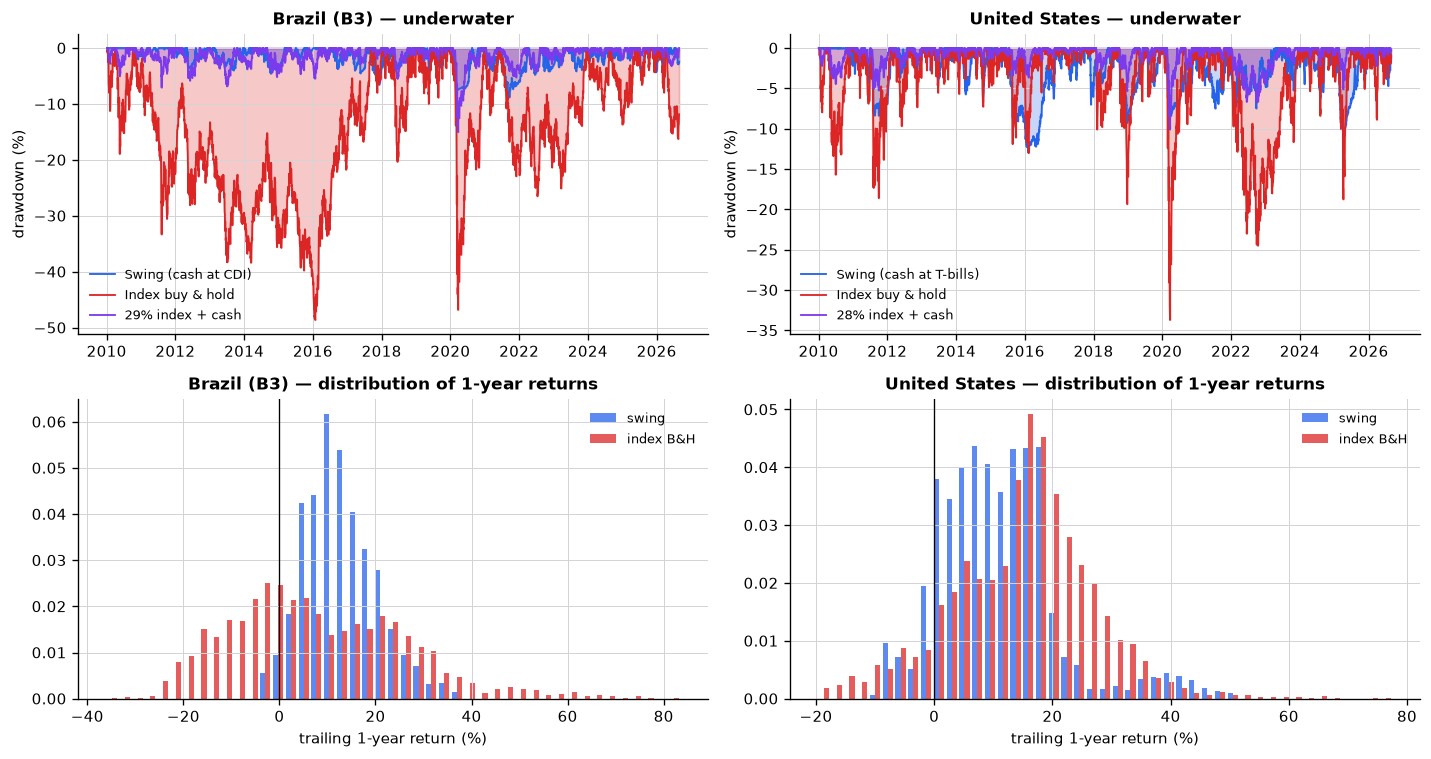

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))

for col, (m, s) in enumerate(STUDIES.items()):
    ax = axes[0][col]
    for name, curve, color in (
        (f"Swing (cash at {s.md.rf_label})", s.swing, S.COLORS["swing"]),
        ("Index buy & hold", s.bench, S.COLORS["index"]),
        (f"{s.exposure_avg:.0%} index + cash", s.blend_exposure, S.COLORS["blend"]),
    ):
        dd = S.drawdown_series(curve)
        ax.fill_between(dd.index, dd * 100, 0, color=color, alpha=0.25)
        ax.plot(dd.index, dd * 100, color=color, lw=1.1, label=name)
    ax.set_title(f"{S.MARKET_LABEL[m]} — underwater")
    ax.set_ylabel("drawdown (%)")
    ax.legend(fontsize=7.5, loc="lower left")

    ax = axes[1][col]
    r = s.rolling_frame()
    ax.hist(
        [r["swing"] * 100, r["index"] * 100],
        bins=45,
        density=True,
        color=[S.COLORS["swing"], S.COLORS["index"]],
        label=["swing", "index B&H"],
        alpha=0.75,
    )
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"{S.MARKET_LABEL[m]} — distribution of 1-year returns")
    ax.set_xlabel("trailing 1-year return (%)")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGDIR / "03_risk.png", bbox_inches="tight")
plt.show()

In [11]:
rows = {}
for m, s in STUDIES.items():
    r = s.rolling_frame()
    down = r["index"] < 0
    rows[S.MARKET_LABEL[m]] = {
        "1y windows": f"{len(r):,}",
        "swing beats index": f"{(r['swing'] > r['index']).mean():.0%}",
        "swing beats blend": f"{(r['swing'] > r['blend']).mean():.0%}",
        "swing beats risk-free": f"{(r['swing'] > r['risk_free']).mean():.0%}",
        "P(swing loses money)": f"{(r['swing'] < 0).mean():.0%}",
        "P(index loses money)": f"{(r['index'] < 0).mean():.0%}",
        "worst swing year": f"{r['swing'].min():.1%}",
        "worst index year": f"{r['index'].min():.1%}",
        "swing when index is down": f"{r['swing'][down].mean():+.1%}",
        "index when index is down": f"{r['index'][down].mean():+.1%}",
        "swing when index is up": f"{r['swing'][~down].mean():+.1%}",
        "index when index is up": f"{r['index'][~down].mean():+.1%}",
    }
pd.DataFrame(rows)

,Brazil (B3),United States
1y windows,"3,886","3,936"
swing beats index,67%,31%
swing beats blend,76%,78%
swing beats risk-free,58%,88%
P(swing loses money),3%,10%
P(index loses money),39%,10%
worst swing year,-4.1%,-9.5%
worst index year,-36.2%,-19.7%
swing when index is down,+8.0%,+0.6%
index when index is down,-9.8%,-7.3%


The asymmetry is stark. In Brazil the index lost money over 39% of all 1-year windows and its
worst year was −36%; the swing book lost money in 3% of windows and its worst year was −4.1%.
In the US the index's worst year was −19.7% against the swing book's −9.5%, and the maximum
drawdown was 33.7% against 13.0%.

The conditional rows are the mechanism. When the index was down over a year, the Brazilian
swing book still averaged **+8.0%** against the index's −9.8%. When the index was up, it made
15.9% against the index's 18.6%. It gives up some of the upside and almost all of the downside
— which is precisely what holding 72% cash does, and precisely what a trend-following exit rule
is supposed to add on top.

So the swing system is not worse. It is *different*: a lower-risk, lower-return asset. The
question is whether that trade is worth making, and there is a clean way to ask it.


## 8. Finding 4 — at equal return, whose risk is worse?

A higher Sharpe ratio with a lower return is only useful if the risk can be scaled up. So:
lever the swing book until its return matches the index, and then compare the risk.

This scales the strategy's *excess* return over the risk-free rate, which scales its volatility
and drawdown roughly in proportion. It ignores borrowing spread, margin calls and path risk,
all of which make the real levered version worse than the arithmetic below.


In [12]:
rows = {}
for m, s in STUDIES.items():
    sw = S.curve_stats(s.swing, s.md.rf_daily)
    bh = S.curve_stats(s.bench, s.md.rf_daily)
    lev = S.leverage_to_match(sw, bh)
    rows[S.MARKET_LABEL[m]] = {
        "swing CAGR": f"{sw['cagr']:.1%}",
        "index CAGR": f"{bh['cagr']:.1%}",
        "leverage needed": "none needed"
        if np.isnan(lev["leverage"])
        else f"{lev['leverage']:.2f}x",
        "levered swing vol": "—" if np.isnan(lev["leverage"]) else f"{lev['volatility']:.1%}",
        "index vol": f"{bh['volatility']:.1%}",
        "levered swing drawdown": "—"
        if np.isnan(lev["leverage"])
        else f"{lev['max_drawdown']:.1%}",
        "index drawdown": f"{bh['max_drawdown']:.1%}",
    }
pd.DataFrame(rows)

,Brazil (B3),United States
swing CAGR,12.4%,10.5%
index CAGR,5.7%,14.2%
leverage needed,none needed,1.40x
levered swing vol,—,11.5%
index vol,22.9%,17.1%
levered swing drawdown,—,-18.1%
index drawdown,-48.6%,-33.7%


In Brazil the question does not arise: the swing book beat the index outright, at a quarter of
the volatility. No leverage required.

In the US it does arise, and the answer is genuinely interesting. To match SPY's 14.2%, the
swing sleeve needs about **1.40x leverage** — and levered to that point it would have run at
11.5% volatility with an 18.1% maximum drawdown, against the index's 17.1% and 33.7%. Same
return, roughly half the drawdown.

That is a real advantage, and it comes with real caveats: 1.4x leverage on a book that trades
228 times a year, financed at a broker's margin rate, through a 2020-style gap. The arithmetic
says it works; the arithmetic is not the part that fails.


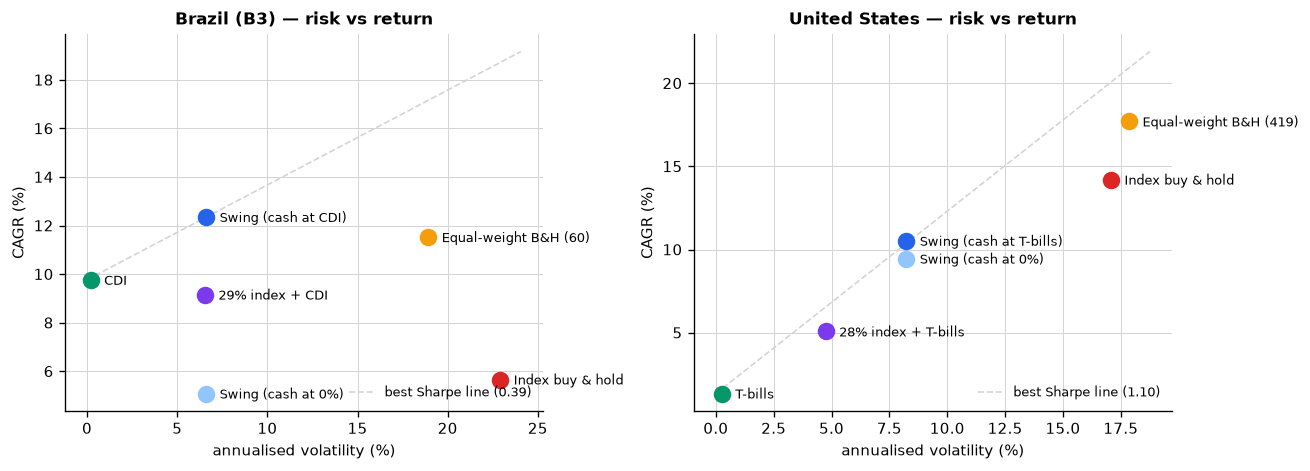

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (m, s) in zip(axes, STUDIES.items()):
    t = s.table()
    for name, row in t.iterrows():
        if "vol-matched" in name:
            continue
        color = (
            S.COLORS["swing_raw"]
            if name.startswith("Swing (cash at 0%)")
            else S.COLORS["swing"]
            if name.startswith("Swing")
            else S.COLORS["index"]
            if name.startswith("Index")
            else S.COLORS["equal_weight"]
            if name.startswith("Equal")
            else S.COLORS["blend"]
            if "index +" in name
            else S.COLORS["risk_free"]
        )
        ax.scatter(row["volatility"] * 100, row["cagr"] * 100, s=90, color=color, zorder=3)
        ax.annotate(
            name,
            (row["volatility"] * 100, row["cagr"] * 100),
            textcoords="offset points",
            xytext=(8, -3),
            fontsize=7.5,
        )
    rf_cagr = S.curve_stats(s.risk_free, s.md.rf_daily)["cagr"] * 100
    xs = np.linspace(0, t["volatility"].max() * 105, 10)
    best = t["sharpe"].max()
    ax.plot(
        xs,
        rf_cagr + best * xs,
        color=S.COLORS["grid"],
        ls="--",
        lw=1,
        label=f"best Sharpe line ({best:.2f})",
    )
    ax.set_xlabel("annualised volatility (%)")
    ax.set_ylabel("CAGR (%)")
    ax.set_title(f"{S.MARKET_LABEL[m]} — risk vs return")
    ax.legend(fontsize=7.5, loc="lower right")
fig.tight_layout()
fig.savefig(FIGDIR / "04_risk_return.png", bbox_inches="tight")
plt.show()

## 9. Finding 5 — how much of the edge survives worse execution

Backtested costs are a guess. The engine charges fees plus a fixed slippage percentage per leg;
reality charges whatever the book gives you on the day. Multiplying the whole cost model by
0x, 1x, 2x and 3x brackets the answer.


In [14]:
from swing_quant.config import load_config

cfg = load_config(S.CONFIG_PATH)
cost_rows = []
for m, s in STUDIES.items():
    panel = S.build_panel_for(s.md, cfg)
    regime = S.build_regime_for(s.md, cfg)
    for mult in (0.0, 1.0, 2.0, 3.0):
        r = S.run_swing(panel, cfg, m, regime=regime, cost_mult=mult)
        curve = S.with_cash_yield(r, s.md.rf_daily)
        st = S.curve_stats(curve, s.md.rf_daily)
        cost_rows.append(
            {
                "market": S.MARKET_LABEL[m],
                "costs": f"{mult:.0f}x",
                "cagr": st["cagr"],
                "sharpe": st["sharpe"],
                "max_drawdown": st["max_drawdown"],
                "trades": len(r.trades),
                "fees paid": float(r.trades["fees"].sum()),
            }
        )
costs_df = pd.DataFrame(cost_rows)
piv = costs_df.pivot(index="costs", columns="market", values="cagr")
display(piv.map("{:.2%}".format))
costs_df

market,Brazil (B3),United States
costs,,
0x,13.17%,11.49%
1x,12.35%,10.52%
2x,11.68%,9.37%
3x,10.84%,8.40%


,market,costs,cagr,sharpe,max_drawdown,trades,fees paid
0,Brazil (B3),0x,0.131690,0.498305,-0.086931,615,0.000000
1,Brazil (B3),1x,0.123544,0.390586,-0.088306,615,3807.414325
2,Brazil (B3),2x,0.116808,0.297065,-0.094400,614,7182.714842
3,Brazil (B3),3x,0.108449,0.182461,-0.099078,614,9994.771659
4,United States,0x,0.114880,1.202587,-0.120001,3796,0.000000
5,United States,1x,0.105246,1.096801,-0.129609,3795,120.991411
6,United States,2x,0.093671,0.972136,-0.138481,3795,214.336391
7,United States,3x,0.083974,0.864722,-0.146518,3793,294.655605


Costs bite, but they do not kill either sleeve. Going from the modelled cost to three times it
takes Brazil from 12.35% to 10.84% and the US from 10.52% to 8.40% — about **0.5 and 0.7
percentage points per turn of the cost dial**. The US sleeve is more fragile because it trades
228 times a year against Brazil's 37.

Worth noting what this does *not* test: it scales slippage uniformly, while real slippage is
worst exactly when you most want to exit. The engine's stop logic already fills at the stop
price or worse on a gap, but a genuine liquidity event is not in this dataset in the way it
would be in a live account.


## 10. Finding 6 — the tax asymmetry

This is the part almost every backtest omits, and it is structural rather than incidental:
**trading realises gains and pays tax on them every month; buying and holding defers tax
indefinitely and pays once, at the end, out of a base that compounded untaxed the whole way.**

Two bills are modelled, because a swing book generates two kinds of income:

- **Trading gains.** In Brazil, 15% on the net gain of each month, with losses carried forward,
  and with the R$20,000 monthly-sales exemption applied where it genuinely applies. In the US,
  a flat 25% stands in for short-term capital gains taxed as ordinary income.
- **Interest on the cash sleeve.** Taxed under a different regime — Brazil's *regressiva* table
  bottoms out at 15% past two years. Two variants are shown: `deferred`, as with a CDB or
  Tesouro Selic held to the end, and `come-cotas`, the semi-annual withholding that applies if
  the cash sits in a fund.

The passive baseline pays 15% once on its whole gain at liquidation.

These are simplified. They are not tax advice, and they ignore the 0.005% withholding, the
day-trade regime, and every wrapper that changes the answer.


In [15]:
TAX = {"b3": S.TAX_BR, "us": S.TAX_US}
rows = {}
for m, s in STUDIES.items():
    rules = TAX[m]
    trade_tax = S.monthly_tax_on_trades(s.result.trades, rules)
    entry = {"tax rules": rules.label}
    for mode in ("deferred", "come_cotas"):
        itax = S.interest_tax_schedule(s.interest, rules, mode=mode)
        after = S.after_tax_curve(s.swing, trade_tax.add(itax, fill_value=0.0))
        entry[f"swing after tax ({mode})"] = f"{S.curve_stats(after, s.md.rf_daily)['cagr']:.2%}"
        entry[f"final ({mode})"] = f"{after.iloc[-1]:,.0f}"
    bh_after = S.deferred_tax_final(s.bench, rules.deferred_rate)
    bh_cagr = (bh_after / s.capital) ** (1 / s.years) - 1
    entry.update(
        {
            "swing pre-tax CAGR": f"{S.curve_stats(s.swing, s.md.rf_daily)['cagr']:.2%}",
            "tax on trades": f"{trade_tax.sum():,.0f}",
            "taxed months": f"{(trade_tax > 0).sum()} of {len(trade_tax)}",
            "index pre-tax CAGR": f"{S.curve_stats(s.bench, s.md.rf_daily)['cagr']:.2%}",
            "index after-tax CAGR": f"{bh_cagr:.2%}",
            "index after-tax final": f"{bh_after:,.0f}",
        }
    )
    rows[S.MARKET_LABEL[m]] = entry
pd.DataFrame(rows)

,Brazil (B3),United States
tax rules,15% on monthly stock gains (R$20k exemption) +...,25% short-term / 15% long-term + 25% on interest
swing after tax (deferred),11.55%,8.12%
final (deferred),"616,187","73,055"
swing after tax (come_cotas),10.91%,8.04%
final (come_cotas),"560,085","72,151"
swing pre-tax CAGR,12.35%,10.52%
tax on trades,"18,316","17,477"
taxed months,37 of 168,68 of 180
index pre-tax CAGR,5.66%,14.20%
index after-tax CAGR,5.06%,13.22%


The drag is roughly **0.8 points a year in Brazil and 2.4 in the US** for the swing book,
against 0.6 and 1.0 for buying and holding. Turnover is taxed; patience is deferred.

Brazil's number is smaller than it looks because two things work in the trader's favour: losses
carry forward and absorb later gains (this system wins only 38% of its trades), and the
R$20,000 monthly-sales exemption genuinely applies in the early years when the book is small.
The US number is bigger because short-term gains are taxed as ordinary income and the sleeve
turns over six times more often.

After every tax, Brazil still favours the swing book (11.55% vs 5.06%) and the US still favours
the index (8.12% vs 13.22%) — taxes widen the existing gap in both cases rather than reversing
it.


## 11. Finding 7 — nobody invests a lump sum

Every number so far assumes a single deposit on day one and no contact with the account for
16.6 years. Almost nobody does that. The realistic pattern is a fixed monthly contribution,
which is money-weighted rather than time-weighted: the returns that matter are the ones that
happened when there was money in the account.

Applying the same contribution schedule to each strategy's daily returns makes the four
comparable on an IRR basis.


In [16]:
rows = []
for m, s in STUDIES.items():
    monthly = s.capital / 100
    for name, curve in (
        ("swing", s.swing),
        ("index B&H", s.bench),
        (s.md.rf_label, s.risk_free),
        ("exposure-matched blend", s.blend_exposure),
    ):
        v, c = S.dca_simulate(curve.pct_change(), monthly)
        rows.append(
            {
                "market": S.MARKET_LABEL[m],
                "into": name,
                "contributed": c.iloc[-1],
                "final value": v.iloc[-1],
                "multiple": v.iloc[-1] / c.iloc[-1],
                "IRR": S.money_weighted_return(v, c),
            }
        )
dca = pd.DataFrame(rows)
dca_show = dca.copy()
dca_show["contributed"] = dca_show["contributed"].map("{:,.0f}".format)
dca_show["final value"] = dca_show["final value"].map("{:,.0f}".format)
dca_show["multiple"] = dca_show["multiple"].map("{:.2f}x".format)
dca_show["IRR"] = dca_show["IRR"].map("{:.2%}".format)
dca_show

,market,into,contributed,final value,multiple,IRR
0,Brazil (B3),swing,"200,000","689,780",3.45x,13.50%
1,Brazil (B3),index B&H,"200,000","459,100",2.30x,9.27%
2,Brazil (B3),CDI,"200,000","485,803",2.43x,9.87%
3,Brazil (B3),exposure-matched blend,"200,000","500,881",2.50x,10.19%
4,United States,swing,"40,000","116,898",2.92x,11.80%
5,United States,index B&H,"40,000","157,796",3.94x,14.87%
6,United States,T-bills,"40,000","47,946",1.20x,2.13%
7,United States,exposure-matched blend,"40,000","66,631",1.67x,5.83%


The ranking survives, but one number moves a lot. Dollar-cost averaging into the Ibovespa
returns an IRR of **9.27%** against a lump-sum CAGR of 5.7% — because Brazil's bad years came
early, when a monthly contributor had almost nothing invested, and its good years came late,
when the account was full. Timing luck, not skill, worth 3.6 points a year.

That is a useful reminder about the whole exercise: a single 16-year path produces point
estimates that are far less precise than they look printed to two decimals.


## 12. What it costs to run

The last column of any honest comparison is the one that is not denominated in money.


In [17]:
rows = {}
for m, s in STUDIES.items():
    t = s.result.trades
    rows[S.MARKET_LABEL[m]] = {
        "trades per year": f"{len(t) / s.years:.0f}",
        "total trades": f"{len(t):,}",
        "average hold": f"{t['bars_held'].mean():.1f} sessions",
        "win rate": f"{(t['pnl'] > 0).mean():.1%}",
        "screening days per year": f"{len(s.index) / s.years:.0f}",
        "orders per year (both legs)": f"{2 * len(t) / s.years:.0f}",
        "buy & hold trades, 16.6 years": "1",
    }
pd.DataFrame(rows)

,Brazil (B3),United States
trades per year,37,228
total trades,615,"3,795"
average hold,23.7 sessions,6.3 sessions
win rate,37.7%,47.0%
screening days per year,249,252
orders per year (both legs),74,456
"buy & hold trades, 16.6 years",1,1


The Brazilian sleeve asks for 37 trades a year — 74 orders, plus a screening run every session.
The US sleeve asks for 228 trades a year, 456 orders. The passive alternative asks for one
order, ever.

At the Brazilian sleeve's residual edge over a cash-matched passive portfolio — 3.2 points a
year — a R$100,000 account earns roughly R$3,200 a year for that work. Whether that is
a good hourly rate depends entirely on the size of the account, which is the real argument for
automating the whole thing and the real limit on it as a strategy for small capital.


## 13. Finding 8 - the backdrop: in Brazil, risk barely paid at all

Everything above compares the swing book against *stocks* and *cash*, because those are the only
two things the engine knows about. That is a narrow slice of what a household can actually own.
This section widens it to every asset class a Brazilian or American investor could realistically
have bought, rebuilt from the same database and ranked by the only number that survives sixteen
years of inflation: the **real** return.

Three of them do not come from the price feed, because the price feed gets them wrong:

- **Listed property funds** come from the B3's own IFIX. Rebuilding the class from individual
  funds understates it by more than four points a year - the price feed only knows the recent
  distributions, and a property fund pays out almost its entire return in cash.
- **Physical property** comes from the central bank's IVG-R, the appraisal index of financed
  homes. It measures what apartments are *worth*, not what they *earn*, so a second row adds
  4% a year of net rent on top.
- **Government bonds** come from the Treasury's own daily price file, marked to market and
  rolled at a fixed target maturity, rather than from an assumed coupon.

Everything is compared on month-end closes, because property and the savings account only exist
monthly. Drawdowns here are therefore month-end drawdowns: shallower than the intraday truth,
but shallower by the same rule for every class.

In [18]:
import asset_classes as A

CLASSES, INFL, CLASS_TABLES, WINDOWS = {}, {}, {}, {}
for m, s in STUDIES.items():
    curves = A.load_classes(m)
    if m == "b3":  # the IVG-R is price-only; rent is the other half of owning a flat
        curves["imoveis_income"] = A.with_income(curves["imoveis"], A.NET_RENTAL_YIELD, "")
    curves["swing"] = A.swing_as_class(s.swing, m, f"Swing quant ({', '.join(s.md.strategies)})")
    CLASSES[m], INFL[m] = curves, A.load_inflation(m)
    CLASS_TABLES[m] = A.stats_table(curves, INFL[m], A.CASH_KEY[m])
    WINDOWS[m] = A.common_window(curves)

for m in STUDIES:
    print(f"\n=== {S.MARKET_LABEL[m]} - real returns, each class over its own history")
    display(A.fmt_stats(CLASS_TABLES[m]))


=== Brazil (B3) - real returns, each class over its own history


,CAGR real,CAGR nominal,Vol.,Max drawdown,Sharpe vs cash,Worst year,Best year,Positive months,Total real,Years
Asset class,,,,,,,,,,
Bitcoin in reais,54.8%,66.4%,72.0%,-74.7%,0.91,-69.1%,1395.5%,57.3%,17483.4%,11.9
S&P 500 in reais,15.0%,21.9%,16.7%,-26.3%,0.70,-22.4%,59.1%,64.3%,903.3%,16.6
Gold in reais,8.8%,15.9%,18.2%,-25.1%,0.38,-17.2%,62.4%,62.8%,302.5%,16.6
Swing quant (donchian),6.4%,12.4%,7.4%,-6.8%,0.34,-3.2%,26.4%,73.4%,178.5%,16.6
Fixed-rate government bond (~4y),4.6%,10.7%,7.5%,-15.7%,0.14,-9.1%,39.6%,71.0%,112.4%,16.7
Floating-rate government bond,4.1%,10.1%,1.0%,-0.4%,0.66,2.3%,14.7%,99.0%,93.2%,16.7
Physical property + net rent (4%),4.0%,10.0%,1.7%,0.0%,0.07,1.1%,25.4%,100.0%,89.9%,16.4
Inflation-linked government bond (~10y),3.9%,10.1%,9.2%,-21.2%,0.07,-16.8%,36.0%,65.0%,89.8%,16.7
CDI (cash),3.9%,9.9%,1.0%,0.0%,-,2.8%,14.3%,100.0%,87.3%,16.7



=== United States - real returns, each class over its own history


,CAGR real,CAGR nominal,Vol.,Max drawdown,Sharpe vs cash,Worst year,Best year,Positive months,Total real,Years
Asset class,,,,,,,,,,
Bitcoin,50.3%,56.2%,71.5%,-75.6%,0.94,-73.6%,1368.9%,55.9%,11947.1%,11.9
Nasdaq 100,16.0%,19.5%,17.6%,-32.6%,1.03,-32.6%,54.9%,63.3%,1048.5%,16.6
US stocks (S&P 500),11.4%,14.6%,14.4%,-23.9%,0.93,-18.2%,32.3%,68.8%,490.8%,16.6
US small caps,8.6%,11.5%,19.5%,-32.3%,0.59,-20.5%,38.7%,62.8%,285.7%,16.6
Swing quant (momentum),7.6%,10.6%,8.6%,-11.0%,1.07,-2.3%,40.6%,67.3%,232.3%,16.6
REITs,6.9%,9.3%,17.2%,-32.8%,0.53,-26.3%,40.5%,60.8%,197.2%,16.6
Gold,4.9%,8.5%,16.6%,-42.9%,0.50,-28.3%,63.7%,51.8%,119.7%,16.6
Developed ex-US,4.7%,7.6%,15.5%,-27.6%,0.47,-14.4%,31.5%,61.3%,111.6%,16.6
Emerging markets,2.4%,5.6%,18.2%,-36.5%,0.32,-20.6%,37.3%,53.3%,48.4%,16.6


The two markets are not two versions of the same story. They are opposites.

**In the United States, cash was the worst asset you could own.** T-bills lost 1.3% a year to
inflation over 16.6 years; stocks made 11.4% above it. Every equity line, the REITs and even
gold beat the money market, and the only losers were the bond funds that a whole generation of
"balanced" portfolios was built around.

**In Brazil, cash beat almost everything.** The CDI returned 3.9% a year above the IPCA - and
nothing a Brazilian could buy with equity risk came close. The Ibovespa made **0.5% a year**
real over the same 16.6 years, with 21% volatility and a 43% drawdown. Small caps *lost* 1.6% a
year. Listed property funds, the country's favourite income asset, made 3.0% - a point below
the money market, with ten times the volatility.

Read that as a sentence: **for sixteen years, the Brazilian equity risk premium was negative.**
An investor who took the full risk of the stock market was paid 3.4 points a year *less* than
one who took none. Only three things beat the CDI by a real margin, and none of them is a
Brazilian risky asset: bitcoin, the S&P 500 in reais, and gold - two of which are simply the
dollar wearing different hats.

The physical-property line deserves its own note. Bare appraisal value returned exactly zero
real over the period - a flat bought in 2010 is worth, in purchasing power, what it cost. Rent
is not the cherry on the cake of Brazilian property; rent *is* the return.

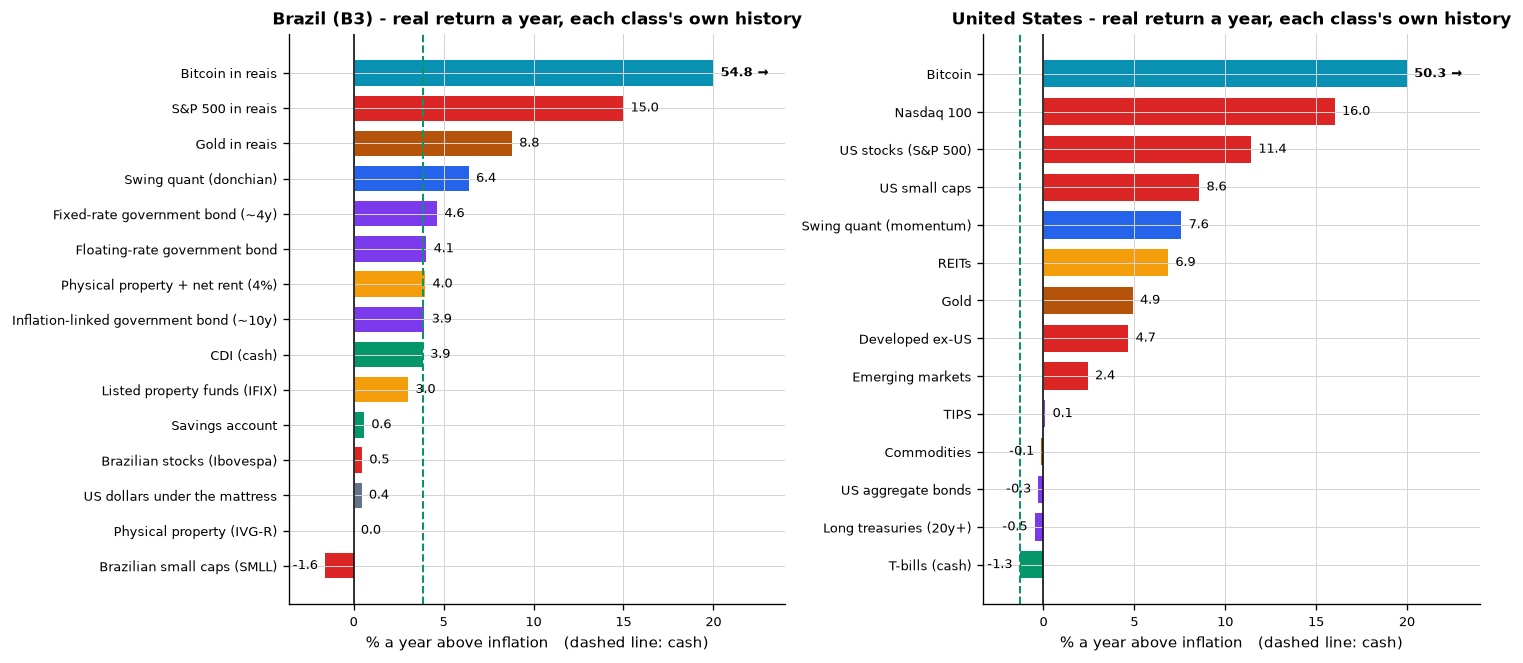

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6))
CAP = 20.0  # bitcoin would flatten every other bar; cap the axis and label it instead
for ax, m in zip(axes, STUDIES):
    t = CLASS_TABLES[m].sort_values("cagr_real")
    colors = A.color_map(CLASSES[m])
    shown = (t["cagr_real"] * 100).clip(upper=CAP)
    ax.barh(t.index, shown, color=[colors[i] for i in t.index], height=0.72)
    ax.axvline(0, color="#111", lw=1)
    ax.axvline(
        t.loc[A.EN_LABEL[A.CASH_KEY[m]], "cagr_real"] * 100, color="#059669", lw=1.2, ls="--"
    )
    for y, (v, x) in enumerate(zip(t["cagr_real"] * 100, shown)):
        ax.text(
            x + (0.4 if v >= 0 else -0.4),
            y,
            f"{v:.1f}" + (" \u2192" if v > CAP else ""),
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=7.6,
            fontweight="bold" if v > CAP else "normal",
        )
    ax.set_xlim(min(-3.0, float((t["cagr_real"] * 100).min()) - 2), CAP + 4)
    ax.set_title(f"{S.MARKET_LABEL[m]} - real return a year, each class's own history")
    ax.set_xlabel("% a year above inflation   (dashed line: cash)")
    ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "09_asset_classes.png", bbox_inches="tight")
plt.show()

In [20]:
# Bitcoin starts in late 2014 and drags the strict window with it; this is the head-to-head
# where every class in the table actually existed at the same time.
for m in STUDIES:
    lo, hi = WINDOWS[m]
    print(f"\n=== {S.MARKET_LABEL[m]} - common window {lo} to {hi}")
    display(A.fmt_stats(A.stats_table(CLASSES[m], INFL[m], A.CASH_KEY[m], window=(lo, hi))))


=== Brazil (B3) - common window 2014-10 to 2026-06


,CAGR real,CAGR nominal,Vol.,Max drawdown,Sharpe vs cash,Worst year,Best year,Positive months,Total real,Years
Asset class,,,,,,,,,,
Bitcoin in reais,54.6%,63.4%,72.2%,-74.7%,0.89,-69.1%,1395.5%,56.7%,16638.7%,11.8
S&P 500 in reais,14.9%,21.4%,18.0%,-26.3%,0.64,-22.4%,59.1%,63.1%,410.3%,11.8
Gold in reais,11.7%,18.1%,17.9%,-23.5%,0.49,-12.0%,62.4%,66.0%,267.6%,11.8
Swing quant (donchian),8.2%,14.4%,8.1%,-6.8%,0.54,-3.2%,26.4%,72.3%,153.0%,11.8
Brazilian stocks (Ibovespa),4.4%,10.3%,21.5%,-37.0%,0.13,-13.3%,38.9%,58.2%,65.8%,11.8
Fixed-rate government bond (~4y),4.3%,10.2%,8.3%,-15.7%,0.08,-9.1%,39.6%,69.5%,64.1%,11.8
Floating-rate government bond,4.2%,10.1%,1.2%,-0.4%,0.67,2.3%,14.7%,98.6%,62.4%,11.8
CDI (cash),4.0%,9.9%,1.1%,0.0%,-,2.8%,14.3%,100.0%,58.3%,11.8
Listed property funds (IFIX),2.9%,8.8%,10.7%,-22.0%,-0.04,-10.2%,36.0%,64.5%,40.6%,11.8



=== United States - common window 2014-10 to 2026-08


,CAGR real,CAGR nominal,Vol.,Max drawdown,Sharpe vs cash,Worst year,Best year,Positive months,Total real,Years
Asset class,,,,,,,,,,
Bitcoin,50.3%,56.2%,71.5%,-75.6%,0.94,-73.6%,1368.9%,55.9%,11947.1%,11.9
Nasdaq 100,15.0%,19.0%,18.5%,-32.6%,0.93,-32.6%,54.9%,63.6%,417.7%,11.9
US stocks (S&P 500),10.4%,13.9%,14.8%,-23.9%,0.83,-18.2%,31.2%,69.2%,221.4%,11.9
Swing quant (momentum),7.6%,10.9%,9.5%,-11.0%,0.95,-2.3%,40.6%,66.4%,135.9%,11.9
Gold,6.9%,11.1%,15.6%,-23.8%,0.64,-10.7%,63.7%,51.7%,120.1%,11.9
US small caps,6.8%,10.0%,20.0%,-32.3%,0.49,-20.5%,25.4%,63.6%,117.2%,11.9
Developed ex-US,4.3%,7.5%,14.6%,-27.6%,0.44,-14.4%,31.5%,62.2%,64.6%,11.9
REITs,4.1%,6.6%,17.4%,-32.8%,0.35,-26.3%,40.5%,59.4%,61.0%,11.9
Emerging markets,2.8%,6.4%,17.3%,-36.5%,0.34,-20.6%,37.3%,55.2%,38.2%,11.9


The strict window shortens the sample by four years and moves two things, both worth naming.

Brazilian stocks look better on it (4.4% real instead of 0.5%) because the window starts *after*
the 2011-2015 bear market, and physical property looks worse (-2.5% instead of 0.0%) because it
starts *after* the boom that ended in 2014. Neither reversal changes the ranking that matters:
in Brazil the money market still beats domestic equities, domestic property and the savings
account, over both windows.

The swing sleeve places well here - 8.2% real in Brazil, 7.6% in the US, at a third of the
volatility of the stock market. But Finding 1 already explained where most of the Brazilian
figure came from, and this table shows the same thing from the outside: a strategy that sits
72% in cash, in a country where cash pays 3.9% real, starts the race most of the way to the
finish line.

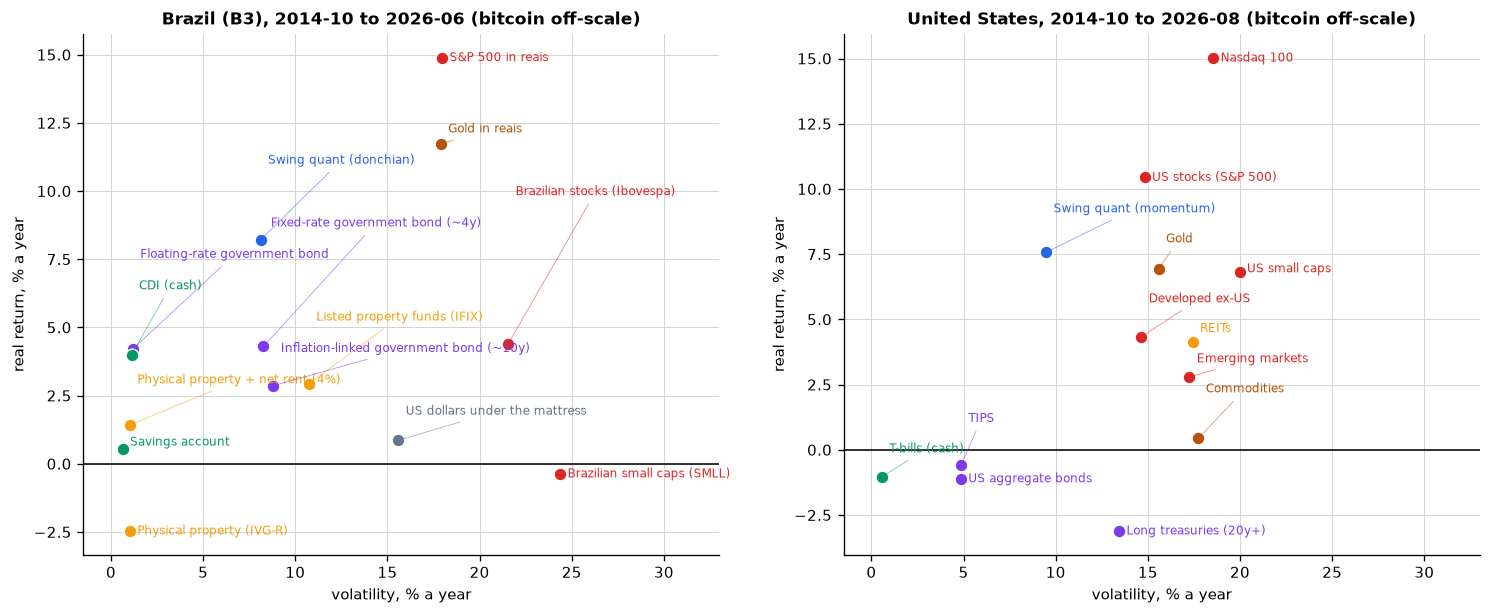

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for ax, m in zip(axes, STUDIES):
    lo, hi = WINDOWS[m]
    t = A.stats_table(CLASSES[m], INFL[m], A.CASH_KEY[m], window=(lo, hi))
    t = t[t.index != A.EN_LABEL["bitcoin_brl" if m == "b3" else "bitcoin_usd"]]
    colors = A.color_map(CLASSES[m])
    points = []
    for label, row in t.iterrows():
        x, y = row["volatility"] * 100, row["cagr_real"] * 100
        ax.scatter(x, y, s=58, color=colors[label], zorder=3, edgecolor="white", lw=0.8)
        points.append((x, y, label, colors[label]))
    A.annotate_scatter(ax, points, min_gap=1.15)
    ax.axhline(0, color="#111", lw=1)
    ax.set_xlim(-1.5, 33)
    ax.set_xlabel("volatility, % a year")
    ax.set_ylabel("real return, % a year")
    ax.set_title(f"{S.MARKET_LABEL[m]}, {lo} to {hi} (bitcoin off-scale)")
fig.tight_layout()
fig.savefig(FIGDIR / "10_risk_return.png", bbox_inches="tight")
plt.show()

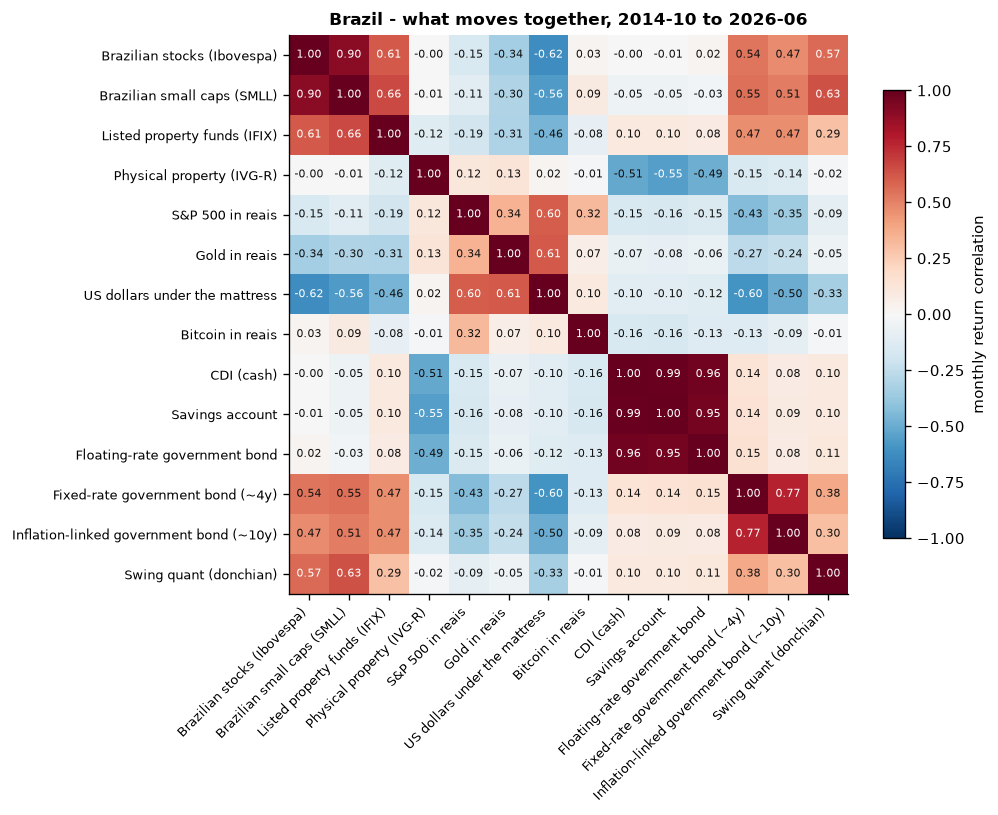

In [22]:
lo, hi = WINDOWS["b3"]
corr = A.correlation_matrix(CLASSES["b3"], (lo, hi))
corr = corr.drop(index=[A.EN_LABEL["imoveis_income"]], columns=[A.EN_LABEL["imoveis_income"]])

fig, ax = plt.subplots(figsize=(8.4, 7.2))
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=7.5)
ax.set_yticks(range(len(corr)), corr.index, fontsize=7.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=6.4,
            color="white" if abs(v) > 0.55 else "#111",
        )
ax.grid(False)
ax.set_title(f"Brazil - what moves together, {lo} to {hi}")
fig.colorbar(im, ax=ax, shrink=0.7, label="monthly return correlation")
fig.tight_layout()
fig.savefig(FIGDIR / "11_correlation.png", bbox_inches="tight")
plt.show()

The correlation matrix explains why the Brazilian result is not simply "everything went down".

Domestic risk assets are one trade. Stocks, small caps and property funds correlate 0.61 to 0.90
with each other: a Brazilian who diversified across the Ibovespa, small caps and FIIs owned
three copies of the same bet. The genuine diversifiers all point abroad - the dollar at -0.62
against the Ibovespa, gold at -0.34 - or nowhere at all: bitcoin correlates 0.03 with Brazilian
stocks, and physical property correlates -0.00, which is less a property of real estate than a
property of appraisal indices, which smooth away the shocks a market price would record.

Cash and the savings account move at 0.99 with each other and at ~0.00 with the stock market,
which is the whole point of them. And the swing sleeve sits at 0.57 with the Ibovespa and 0.10
with the CDI: two thirds cash by weight, but still an equity product by behaviour.

## 14. What would change these numbers

- **Survivorship bias.** The universe is today's index membership walked backwards. This helps
  the passive baselines most and the equal-weight baseline enormously — treat its 17.7% US
  figure as an unreachable ceiling.
- **One path.** Every point estimate is a single draw from 16.6 years. The rolling-window
  sections give some spread; they are not a substitute for a proper distribution.
- **In-sample parameters.** Donchian's 40/10 lookbacks and momentum's 189/21 were selected by
  the project's validation protocol on the training portion, but they were selected on *this*
  data. The passive baselines have no parameters to select.
- **Cash yield is a broker decision.** The Brazilian result assumes the broker pays 100% of CDI
  on idle balances. Many do; some pay nothing. At 0% the same system makes 5.1% a year instead
  of 12.4%, and loses to a savings account.
- **Rates are not stable.** The Brazilian result rests on a period when CDI averaged 9.8%. At
  Selic near 2%, as in 2020, more than half of the swing return simply disappears.
- **No borrowing costs.** The leverage section is arithmetic, not a financing model.
- **Taxes are simplified.** No wrappers, no day-trade regime, no 0.005% withholding, and a flat
  stand-in rate for US short-term gains.


## 15. Conclusion

**The naive question — "did the strategy beat the index?" — is not answerable, because the two
things do not hold the same amount of equity risk.** A swing book sized by volatility is 72%
cash. Comparing it to a fully invested index measures the equity market's mood over the sample,
not the trading rules.

Asking the right question gives a much smaller and much more trustworthy answer. Against a
passive portfolio holding the same average exposure, the Brazilian sleeve earned **3.2
percentage points a year**, stably, across every interest-rate regime. That is real, and it is
roughly half of what the index comparison advertises.

**Where the money came from is not where people think.** In Brazil, 56% of the swing strategy's
compound return was interest on cash it never deployed. The trading contributed 5.08 points and
the money market contributed 6.92. A swing book in a high-rate country is a fixed-income product
with an equity overlay, and it should be marketed, benchmarked and taxed as one.

**Risk-adjusted, the trader wins; in absolute wealth, the investor usually wins.** The swing
book has a higher Sharpe ratio than the index in both markets and roughly a third of the
drawdown. It still ended 16.6 years with US$106k against the index's US$182k, because the risk
it declined to take was risk that paid. Converting a better Sharpe into more money requires
leverage — 1.4x in the US case — and leverage is where paper strategies go to die.

**The environment decides.** The same engine, the same risk rules, the same discipline produced
a clear win in Brazil and a clear loss in the US, and the difference is mostly CDI at 9.8%
versus T-bills at 1.3%. Anyone reporting a swing-trading track record from Brazil over the last
decade is reporting, in large part, the Selic rate.

So: not "trading beats investing" or the reverse. **Trading buys a different risk profile at a
real but modest price, and in Brazil the money-market leg has been doing most of the work.**


## 16. Export

Dumps the figures the article quotes, so the write-up and the notebook cannot drift apart.


In [23]:
import json

export = {}
TAX = {"b3": S.TAX_BR, "us": S.TAX_US}
for m, s in STUDIES.items():
    t = s.table()
    r = s.rolling_frame()
    rq = s.rate_quartiles()
    down = r["index"] < 0
    export[m] = {
        "label": S.MARKET_LABEL[m],
        "currency": s.md.currency,
        "rf_label": s.md.rf_label,
        "capital": s.capital,
        "years": s.years,
        "start": str(s.index[0].date()),
        "end": str(s.index[-1].date()),
        "n_tickers": len(s.md.tickers),
        "n_trades": len(s.result.trades),
        "trades_per_year": len(s.result.trades) / s.years,
        "win_rate": float((s.result.trades["pnl"] > 0).mean()),
        "avg_hold": float(s.result.trades["bars_held"].mean()),
        "exposure_avg": s.exposure_avg,
        "cash_weight_avg": float(s.cash_weight.mean()),
        "table": {
            k: {kk: (None if pd.isna(vv) else float(vv)) for kk, vv in v.items()}
            for k, v in t.to_dict("index").items()
        },
        "attribution": s.attribution(),
        "rate_quartiles": rq.reset_index().to_dict("records"),
        "corr_vs_index": rq.attrs["corr_vs_index"],
        "corr_vs_blend": rq.attrs["corr_vs_blend"],
        "rolling": {
            "n": int(len(r)),
            "swing_beats_index": float((r["swing"] > r["index"]).mean()),
            "swing_beats_blend": float((r["swing"] > r["blend"]).mean()),
            "p_swing_loss": float((r["swing"] < 0).mean()),
            "p_index_loss": float((r["index"] < 0).mean()),
            "worst_swing": float(r["swing"].min()),
            "worst_index": float(r["index"].min()),
            "swing_when_index_down": float(r["swing"][down].mean()),
            "index_when_index_down": float(r["index"][down].mean()),
            "swing_when_index_up": float(r["swing"][~down].mean()),
            "index_when_index_up": float(r["index"][~down].mean()),
        },
        "curves": {
            name: {
                str(d.date()): round(float(v), 2)
                for d, v in curve.resample("ME").last().dropna().items()
            }
            for name, curve in s.curves().items()
        },
        # month-by-month *worst* drawdown, so resampling does not flatten the troughs
        "drawdown": {
            name: {
                str(d.date()): round(float(v), 5)
                for d, v in S.drawdown_series(curve).resample("ME").min().dropna().items()
            }
            for name, curve in (("swing", s.swing), ("index", s.bench), ("blend", s.blend_exposure))
        },
    }

    rules = TAX[m]
    trade_tax = S.monthly_tax_on_trades(s.result.trades, rules)
    tax_entry = {
        "label": rules.label,
        "trade_tax": float(trade_tax.sum()),
        "taxed_months": int((trade_tax > 0).sum()),
        "months": int(len(trade_tax)),
    }
    for mode in ("deferred", "come_cotas"):
        itax = S.interest_tax_schedule(s.interest, rules, mode=mode)
        after = S.after_tax_curve(s.swing, trade_tax.add(itax, fill_value=0.0))
        tax_entry[f"swing_{mode}_cagr"] = S.curve_stats(after, s.md.rf_daily)["cagr"]
        tax_entry[f"swing_{mode}_final"] = float(after.iloc[-1])
        tax_entry[f"interest_tax_{mode}"] = float(itax.sum())
    bh_after = S.deferred_tax_final(s.bench, rules.deferred_rate)
    tax_entry["index_after_final"] = bh_after
    tax_entry["index_after_cagr"] = (bh_after / s.capital) ** (1 / s.years) - 1
    export[m]["taxes"] = tax_entry
    export[m]["leverage"] = S.leverage_to_match(
        S.curve_stats(s.swing, s.md.rf_daily), S.curve_stats(s.bench, s.md.rf_daily)
    )

# --- asset classes (section 13)
STAT_COLS = ["cagr_real", "cagr_nominal", "volatility", "max_drawdown", "sharpe", "years"]


def _class_rows(m, window=None):
    t = A.stats_table(CLASSES[m], INFL[m], A.CASH_KEY[m], window=window)
    kinds = A.asset_class_of(CLASSES[m])
    colors = A.color_map(CLASSES[m])
    return [
        {
            "label": label,
            "asset_class": kinds[label],
            "color": colors[label],
            **{c: (None if pd.isna(row[c]) else float(row[c])) for c in STAT_COLS},
        }
        for label, row in t.iterrows()
    ]


export["asset_classes"] = {
    "net_rental_yield": A.NET_RENTAL_YIELD,
    "note": "monthly closes; real = deflated by IPCA (BR) / CPI (US)",
    "markets": {
        m: {
            "label": S.MARKET_LABEL[m],
            "inflation_cagr": float((1 + INFL[m]).prod() ** (12 / len(INFL[m])) - 1),
            "full": _class_rows(m),
            "common": _class_rows(m, WINDOWS[m]),
            "window": [str(WINDOWS[m][0]), str(WINDOWS[m][1])],
            "curves": {
                A.label_of(c): {
                    str(p): round(float(v), 2)
                    for p, v in (100 * (1 + A.deflate(c.returns, INFL[m])).cumprod()).items()
                }
                for c in CLASSES[m].values()
            },
        }
        for m in STUDIES
    },
    "correlation_b3": {
        "labels": list(corr.columns),
        "matrix": [[round(float(v), 3) for v in row] for row in corr.to_numpy()],
        "window": [str(WINDOWS["b3"][0]), str(WINDOWS["b3"][1])],
    },
}

export["costs"] = costs_df.to_dict("records")
export["dca"] = dca.to_dict("records")

out = Path("study_results.json")
out.write_text(json.dumps(export, indent=1, default=str), encoding="utf-8")
print(f"wrote {out} ({out.stat().st_size / 1024:.0f} KB)")

wrote study_results.json (298 KB)
